In [26]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from joystick_inversion.system import make_dataset
from joystick_inversion.parameters import calibration_values, magnetization_values

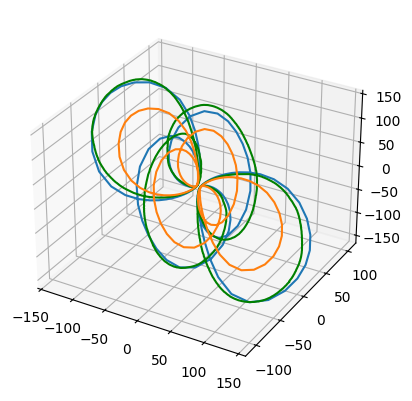

In [ ]:

direction = "east"

calibrated_path = Path("../data/calibrated")
measurement_path = Path("../data/measurement")
precalibrated_path = Path("../data/pre_calibrated")


def get_B(path, direction) -> np.ndarray:
    for file in path.iterdir():
        if direction in file.__str__():
            data = np.load(file)
            return data["B"]

    raise ValueError("not found a file")


B_calibrated = get_B(path=calibrated_path, direction=direction)
B_measurement = get_B(path=measurement_path, direction=direction)
B_precalibrated = get_B(path=precalibrated_path, direction=direction)


fig = plt.figure(2)
ax = fig.add_subplot(111, projection="3d")

Bfields = [B_calibrated, B_measurement, B_precalibrated]

ax.plot(B_calibrated[:, 0], B_calibrated[:, 1], B_calibrated[:, 2])
ax.plot(B_measurement[:, 0], B_measurement[:, 1], B_measurement[:, 2], c="green")
ax.plot(B_precalibrated[:, 0], B_precalibrated[:, 1], B_precalibrated[:, 2])
plt.show()

In [31]:

df = make_dataset(
    n_simulations=3,
    calibration=calibration_values(),
    magnetizations=magnetization_values(),
    seed=1,
    n_steps=240,
)
df = df[["Bx", "By", "Bz", "tilt"]]
df = df[df["tilt"] == 2]
B_simulation = df[["Bx", "By", "Bz"]].to_numpy() * 1e3


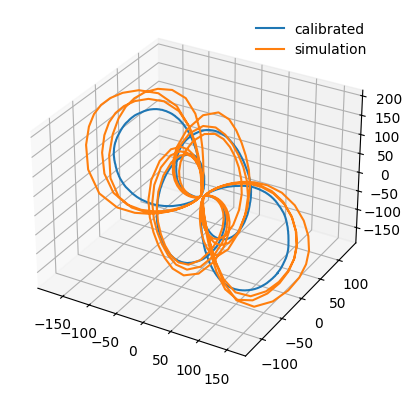

In [32]:
fig = plt.figure(2)
ax = fig.add_subplot(111, projection="3d")

ax.plot(
    B_measurement[:, 0],
    B_measurement[:, 1],
    B_measurement[:, 2],
    label="calibrated",
)

ax.plot(
    B_simulation[:, 0],
    B_simulation[:, 1],
    B_simulation[:, 2],
    label="simulation",
)

plt.legend(frameon=False)
plt.show()